Example of analysis setup 

In [7]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2
using DataFrames
using CSV

In [8]:
using Revise
using Newtrinos
using Newtrinos.osc

In [9]:

osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NNM(),  # The model can be changed here
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

physics = (; osc);


experiments = (
# one or more experiments can be added here
   gerda=Newtrinos.gerda.configure(physics),
);



[ Info: Loading Gerda data


In [10]:
par= Newtrinos.get_params(experiments)
all_priors = Newtrinos.get_priors(experiments)


vars_to_scan = (r=31,  N=31)  

modified_priors = (
    N = Uniform(2, 50),
    m₀ =all_priors.m₀,
    r = all_priors.r,
    
   
  

    Δm²₂₁ = par.Δm²₂₁,
    Δm²₃₁ = par.Δm²₃₁,
    δCP = par.δCP,
    θ₁₂ = par.θ₁₂,
    θ₁₃ = par.θ₁₃,
    θ₂₃ = par.θ₂₃
)

(N = Uniform{Float64}(a=2.0, b=50.0), m₀ = LogUniform{Float64}(a=1.0e-6, b=0.1), r = LogUniform{Float64}(a=1.0e-6, b=1.0), Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [11]:
likelihood_NN = Newtrinos.generate_likelihood(experiments);

result= Newtrinos.scan(likelihood_NN, modified_priors, vars_to_scan, par) # profile option can be used

Number of threads: 4
Total points to compute: 961


Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


TIMING STATISTICS:
  Min time per point: 0.0 ms
  Max time per point: 356.0 ms
  Mean time per point: 0.8 ms
  Median time per point: 0.2 ms
TOTAL TIME:
  Total seconds: 0.81
  Total minutes: 0.01


NewtrinosResult((r = [1.0e-6, 1.5848931924611132e-6, 2.51188643150958e-6, 3.9810717055349725e-6, 6.309573444801931e-6, 9.999999999999997e-6, 1.5848931924611134e-5, 2.5118864315095798e-5, 3.9810717055349715e-5, 6.30957344480193e-5  …  0.015848931924611117, 0.02511886431509577, 0.03981071705534974, 0.06309573444801934, 0.1, 0.15848931924611134, 0.251188643150958, 0.39810717055349715, 0.6309573444801929, 0.9999999999999994], N = [2.0, 3.6, 5.2, 6.800000000000001, 8.4, 10.0, 11.600000000000001, 13.2, 14.8, 16.4  …  35.599999999999994, 37.199999999999996, 38.800000000000004, 40.400000000000006, 42.0, 43.6, 45.2, 46.8, 48.4, 50.0]), (m₀ = [0.01 0.01 … 0.01 0.01; 0.01 0.01 … 0.01 0.01; … ; 0.01 0.01 … 0.01 0.01; 0.01 0.01 … 0.01 0.01], Δm²₂₁ = [7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; … ; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5], Δm²₃₁ = [0.0024752999999999997 0.0024752999999999997 … 0.0024752999999999997 0.0024752999999999997; 0.00247

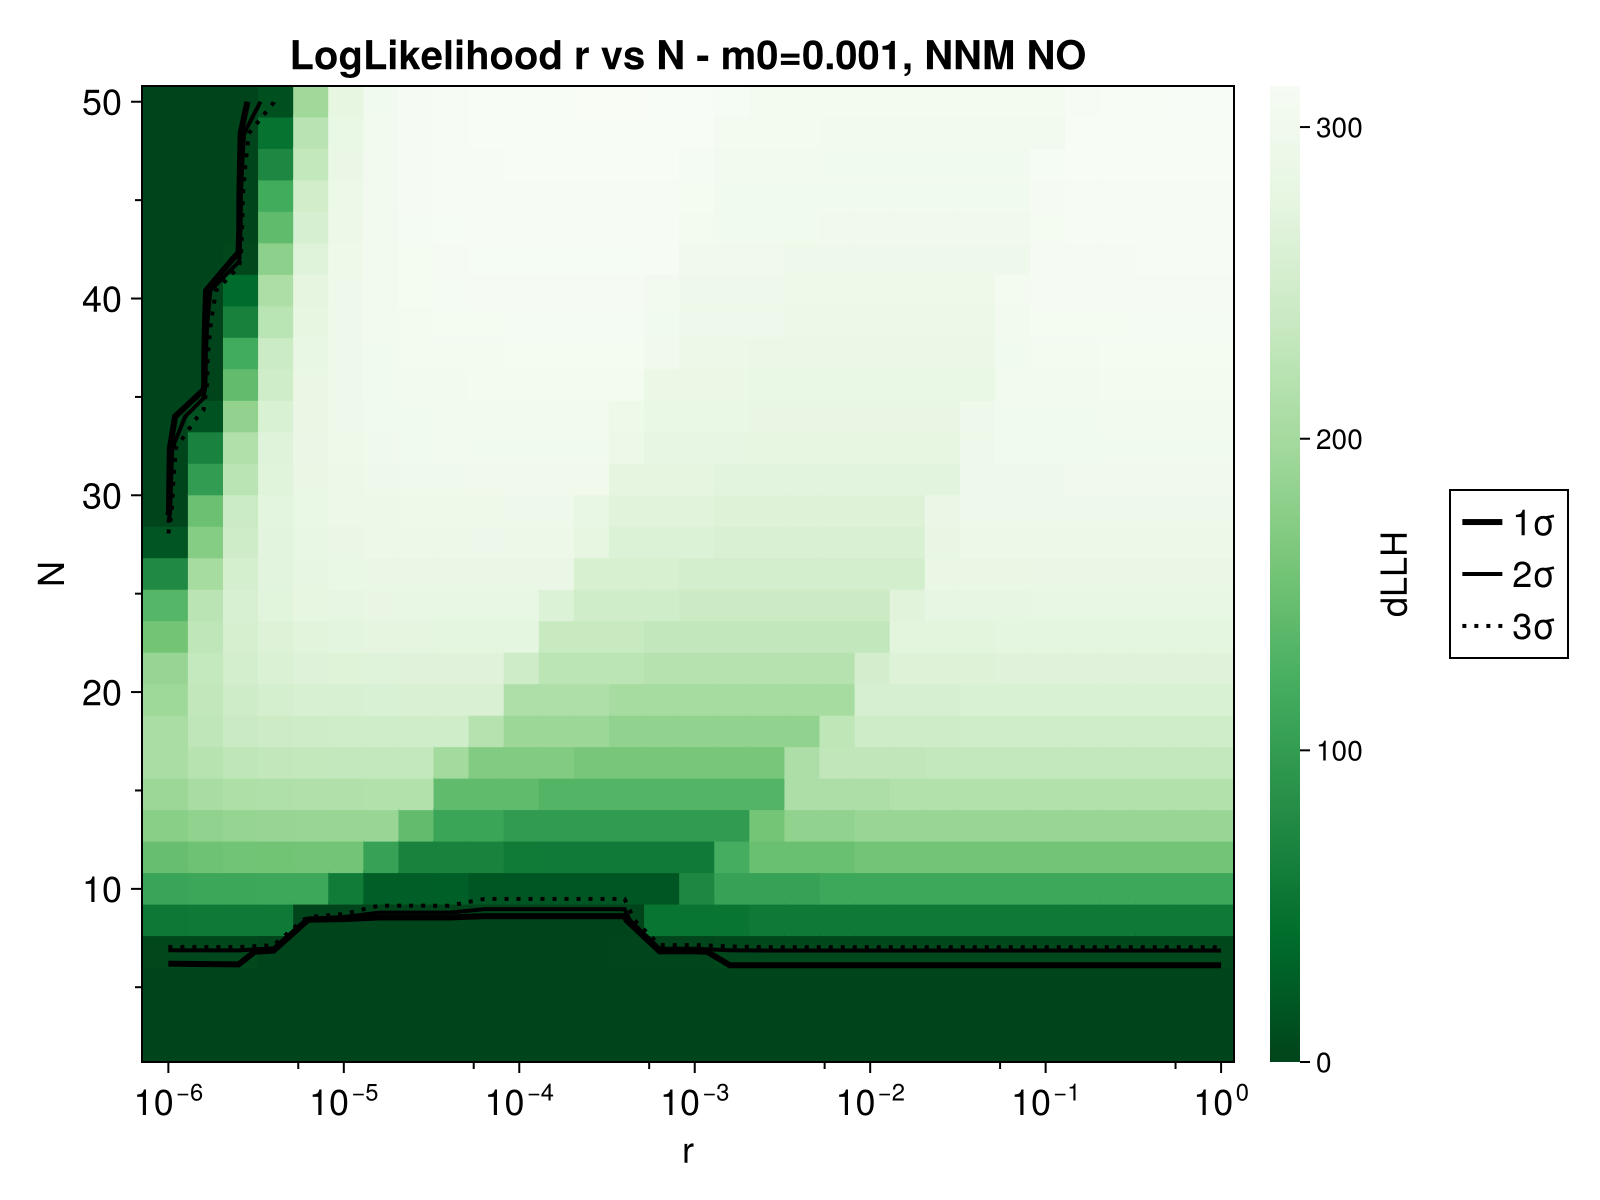

In [12]:
#plot the image
using CairoMakie
img = CairoMakie.plot(result; title="LogLikelihood r vs N - m0=0.001, NNM NO", log=1)
display("image/png", img)
